In [29]:
import pandas as pd
import re
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent.resolve()))
from src.paths import *
import numpy as np

In [30]:
df = pd.read_excel(VALIDATION_SAMPLE)

## Tecnologies

In [31]:
def encontrar_linguagem_robusta(tags_texto, linguagens_alvo):
    """
    Verifica se alguma linguagem alvo está presente na string de tags,
    usando uma regex robusta para lidar com caracteres especiais (+, #).
    """
    if pd.isna(tags_texto) or not tags_texto.strip():
        return 'n/a'

    tags_texto_lower = tags_texto.lower()

    for lang in linguagens_alvo:
        lang_lower = lang.lower()
        lang_escaped = re.escape(lang_lower)
        
        regex_busca = r'(^|,\s*)' + lang_escaped + r'(\s*,|$)'
    
        if re.search(regex_busca, tags_texto_lower):
            return lang
            
    return 'n/a'


LANGUAGES = ['Python', 'JavaScript', 'Java', 'PHP', 'C++', 'C#', 'C', 'Obj-C', 'Go',
              'Perl', 'Ruby', 'Delphi', 'Powershell', 'SQL', 'TSQL', 'Vbnet', 'Lisp', 'Lua', 'Bash',
              'R', 'Haskell', 'Matlab', 'Rust']
LOWERCASE_LANGUAGES = [lang.lower() for lang in LANGUAGES]

df['language'] = df['technologies'].str.lower().apply(
    lambda x: encontrar_linguagem_robusta(x, LANGUAGES)
)

In [32]:
languages = df['language'].value_counts() / df.shape[0] * 100
languages

language
n/a           58.028169
Java           9.014085
PHP            7.605634
Python         7.605634
C#             6.197183
C++            3.661972
Bash           1.408451
C              1.408451
Rust           0.845070
JavaScript     0.845070
Ruby           0.845070
Go             0.563380
SQL            0.563380
Lua            0.281690
Matlab         0.281690
Haskell        0.281690
R              0.281690
Powershell     0.281690
Name: count, dtype: float64

In [33]:
languages = languages.drop('n/a', errors='ignore')

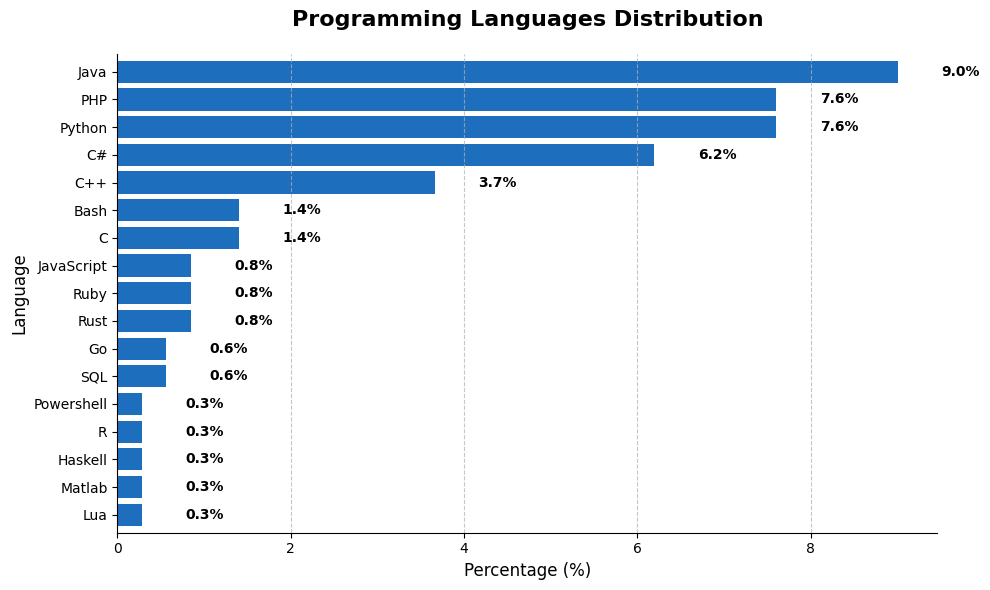

In [34]:
import matplotlib.pyplot as plt

languages = languages.sort_values(ascending=True)

plt.figure(figsize=(10, 6))

ax = languages.plot.barh(color="#1e6ebe", width=0.8)

# Títulos e Rótulos (Fontes maiores para publicação)
plt.title('Programming Languages Distribution', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Percentage (%)', fontsize=12)
plt.ylabel('Language', fontsize=12)

# Adicionar os valores percentuais ao lado das barras
for i, v in enumerate(languages):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')

# --- Estética de Artigo (Limpeza Visual) ---
ax.spines['top'].set_visible(False)    # Remove borda superior
ax.spines['right'].set_visible(False)  # Remove borda direita
ax.grid(axis='x', linestyle='--', alpha=0.7) # Grade discreta apenas no eixo X
plt.tight_layout()

plt.show()

In [35]:
def remove_languages_from_technologies(tech_string, languages_to_remove):
    """
    Remove as linguagens especificadas da string de tecnologias.
    """
    if pd.isna(tech_string) or not tech_string.strip():
        return 'N/a'
    
    tech_list = [tech.strip() for tech in tech_string.split(',')]
    filtered_list = [tech for tech in tech_list if tech.lower() not in [lang.lower() for lang in languages_to_remove]]
    
    # Join back
    return ', '.join(filtered_list) if filtered_list else 'N/a'

# Remove languages from technologies column
df['technologies_clean'] = df['technologies'].apply(lambda x: remove_languages_from_technologies(x, LANGUAGES))

In [36]:
def normalize_technology_terms(cell: str) -> str:
    if not isinstance(cell, str):
        return cell

    normalization_map = {
        "aes-128": "aes",
        "aes-256": "aes",
        "rijndael": "aes",
        "aes-ni": "aes",

        "pkcs1": "pkcs",
        "pkcs#1": "pkcs",
        "pkcs5": "pkcs",
        "pkcs#5": "pkcs",
        "pkcs7": "pkcs",
        "pkcs#7": "pkcs",
        "pkcs11": "pkcs",
        "pkcs11.net": "pkcs",
        "pkcs11interop": "pkcs",
        "pkcs12": "pkcs",
        "pkcs#12": "pkcs",

        "sha1": "sha1",
        "sha-1": "sha1",
        "sha256": "sha",
        "sha-256": "sha",
        "sha512": "sha",
        "sha-512": "sha",
        "sha2": "sha",
    }

    normalized_terms = []

    for term in cell.split(","):
        t = term.strip().lower()
        t = re.sub(r"\s+", " ", t)
        normalized_terms.append(normalization_map.get(t, t))

    return ", ".join(normalized_terms)


df['technologies_clean'] = df['technologies_clean'].apply(normalize_technology_terms)


In [37]:
exploded = (
    df['technologies_clean']
        .str.split(',')
        .explode()
        .str.strip()
        .str.replace('\xa0', '', regex=False)
        .str.lower()
        .replace('', pd.NA)
        .dropna()
)
contagem_palavras_clean = exploded.value_counts()

In [38]:
pd.set_option('display.max_rows', None)
contagem_palavras_clean / df.shape[0] * 100

technologies_clean
openssl                      20.281690
aes                          16.056338
sha                          13.521127
md5                          10.704225
rsa                          10.140845
ssl                           8.169014
n/a                           7.887324
pkcs                          5.915493
.net                          5.352113
hash                          4.225352
base64                        4.225352
iv                            3.943662
sha1                          3.943662
tls                           3.661972
xor                           3.380282
cbc                           3.098592
bcrypt                        2.816901
pgp                           2.535211
mysql                         1.690141
ctr                           1.408451
bouncycastle                  1.408451
ssh                           1.408451
ecb                           1.408451
pbkdf                         1.408451
mac                           1.126761
dicewa

## Tecnologies along topics

In [39]:
TOP_N = 99999

if 'technologies_clean' not in df.columns:
    if 'technologies' in df.columns:
        df['technologies_clean'] = df['technologies'].apply(lambda x: remove_languages_from_technologies(x, LANGUAGES))
        df['technologies_clean'] = df['technologies_clean'].apply(normalize_technology_terms)
    else:
        raise ValueError("Coluna 'technologies' não encontrada no dataframe. Não é possível extrair tecnologias.")

# Explode tecnologias por post (usar índice como identificador do post)
tmp = df[['topic', 'technologies_clean']].copy()
tmp['post_id'] = tmp.index
tmp = tmp.dropna(subset=['topic'])  # pular tópicos ausentes
tmp = tmp.dropna(subset=['technologies_clean'])
tmp = tmp.assign(tech=tmp['technologies_clean'].str.split(',')).explode('tech')
tmp['tech'] = (tmp['tech'].astype(str)
                   .str.strip()
                   .str.replace('\xa0', '', regex=False)
                   .str.lower())
tmp = tmp[~tmp['tech'].isin(['', 'n/a', 'na', 'N/a'])]

all_topics = sorted(df['topic'].dropna().unique())

for topic in all_topics:
    posts_in_topic = df[df['topic'] == topic].shape[0]
    topic_techs = tmp[tmp['topic'] == topic]
    if topic_techs.empty:
        print(f"Tópico: {topic} — nenhuma tecnologia encontrada (posts: {posts_in_topic})\n")
        continue

    tech_post_counts = topic_techs.groupby('tech')['post_id'].nunique().sort_values(ascending=False)
    top = tech_post_counts.head(TOP_N)

    print(f"{topic} (posts: {posts_in_topic})")
    for i, (tech, count) in enumerate(top.items(), start=1):
        pct = (count / posts_in_topic * 100) if posts_in_topic > 0 else 0
        print(f"  {i}. {tech} — {pct:.1f}%")
    print()

Application data encryption & key storage (posts: 12)
  1. aes — 50.0%
  2. mysql — 25.0%
  3. iv — 16.7%
  4. codeigniter — 8.3%
  5. cryptojs — 8.3%
  6. django — 8.3%
  7. itsdangerous — 8.3%
  8. .net — 8.3%
  9. key rotation — 8.3%
  10. mcrypt — 8.3%
  11. pandas — 8.3%
  12. rsa — 8.3%
  13. sha — 8.3%
  14. sqlcipher — 8.3%
  15. sqlite — 8.3%
  16. xor — 8.3%

Block cipher modes, IV/nonce, and padding (posts: 21)
  1. aes — 61.9%
  2. iv — 42.9%
  3. cbc — 42.9%
  4. xor — 33.3%
  5. ecb — 23.8%
  6. ctr — 23.8%
  7. mac — 19.0%
  8. pkcs — 19.0%
  9. gcm — 14.3%
  10. rsa — 9.5%
  11. xex — 9.5%
  12. cpa-security — 9.5%
  13. cca — 9.5%
  14. blowfish — 4.8%
  15. asp.net — 4.8%
  16. aead — 4.8%
  17. aad — 4.8%
  18. eme — 4.8%
  19. cfb — 4.8%
  20. bouncycastle — 4.8%
  21. hmac — 4.8%
  22. m-cca2 — 4.8%
  23. kcv — 4.8%
  24. jizz-jazz — 4.8%
  25. jce — 4.8%
  26. pgp — 4.8%
  27. otp — 4.8%
  28. oaep — 4.8%
  29. ofb — 4.8%
  30. rfc — 4.8%
  31. prp — 4.8%
  32. rs

## Tecnologies along time

In [40]:
df = pd.read_csv(CLASSIFIED_POSTS)
df = df[df['type'] == 'question']

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\dev\\social-media-dev-crawler\\data\\Lda\\csvs\\classified_posts.csv'

In [ ]:
import matplotlib.pyplot as plt


df['creation_date'] = pd.to_datetime(df['creation_date'], errors='coerce')

df['year'] = df['creation_date'].dt.year

topic_by_year = df.groupby(['year', 'topic']).size().reset_index(name='count')

total_by_year = df.groupby('year').size().reset_index(name='total')

topic_by_year = topic_by_year.merge(total_by_year, on='year')
topic_by_year['percentage'] = (topic_by_year['count'] / topic_by_year['total']) * 100

all_topics = sorted(df['topic'].unique())
n_topics = len(all_topics)

print(f"Total de tópicos: {n_topics}")

fig, axes = plt.subplots(n_topics, 1, figsize=(9, 1.5 * n_topics), sharex=True)

if n_topics == 1:
    axes = [axes]

colors = plt.cm.tab10(range(10))

for idx, topic in enumerate(all_topics):
    ax = axes[idx]
    
    ax2 = ax.twinx()

    topic_data = topic_by_year[topic_by_year['topic'] == topic].sort_values('year')
    
    if not topic_data.empty:
        color = colors[idx % 10]
        
        line1 = ax.plot(topic_data['year'], topic_data['count'], 
                        marker='o', linewidth=2, markersize=4, 
                        color=color, label='Contagem (eixo esq.)',
                        linestyle='-', alpha=0.8)
        
        line2 = ax2.plot(topic_data['year'], topic_data['percentage'], 
                         marker='s', linewidth=2, markersize=3,
                         color=color, label='Porcentagem (eixo dir.)',
                         linestyle='--', alpha=0.6)
    
    ax.set_ylabel('Contagem', fontsize=8, fontweight='bold')
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    
    ax2.set_ylabel('Porcentagem', fontsize=8, fontweight='bold', rotation=270, labelpad=12)
    ax2.tick_params(axis='y', labelsize=7)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
    
    ax.set_title(f'{topic}', fontsize=9, fontweight='bold', loc='left', pad=3)
    
    if idx < n_topics - 1:
        ax.tick_params(labelbottom=False)
    
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, ['Contagem (esq.)', 'Porcentagem (dir.)'], 
              loc='upper right', fontsize=6, framealpha=0.9)

axes[-1].set_xlabel('Ano', fontsize=9, fontweight='bold')
axes[-1].tick_params(axis='x', labelsize=8, rotation=45)

plt.suptitle('Evolução dos Tópicos ao Longo do Tempo — Contagem e Porcentagem', 
             fontsize=12, fontweight='bold', y=0.998)
plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.show()